# Import the Libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Statistical tests
from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Read the Dataset

In [ ]:
df = pd.read_csv('Islander_data.csv')
df.head(10)

,first_name,last_name,age,Happy_Sad_group,Dosage,Drug,Mem_Score_Before,Mem_Score_After,Diff
0,Bastian,Carrasco,25,H,1,A,63.5,61.2,-2.3
1,Evan,Carrasco,52,S,1,A,41.6,40.7,-0.9
2,Florencia,Carrasco,29,H,1,A,59.7,55.1,-4.6
3,Holly,Carrasco,50,S,1,A,51.7,51.2,-0.5
4,Justin,Carrasco,52,H,1,A,47.0,47.1,0.1
5,Liam,Carrasco,37,S,1,A,66.4,58.1,-8.3
6,Ava,Durand,35,S,1,A,44.1,56.0,11.9
7,Jamie,Durand,38,H,1,A,76.3,74.8,-1.5
8,Josefa,Durand,29,H,1,A,56.2,45.0,-11.2
9,Mark,Durand,36,S,1,A,54.8,75.9,21.1


# Explore the Dataset

In [ ]:
# Check number of rows and columns
df.shape

(198, 9)

The dataset contains 198 rows and 9 columns. Each row represents one participant in the memory test experiment.

In [ ]:
# Display all column names
df.columns

Index(['first_name', 'last_name', 'age', 'Happy_Sad_group', 'Dosage', 'Drug', 'Mem_Score_Before', 'Mem_Score_After', 'Diff'], dtype='object')

In [ ]:
# Check data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   first_name        198 non-null    object 
 1   last_name         198 non-null    object 
 2   age               198 non-null    int64  
 3   Happy_Sad_group   198 non-null    object 
 4   Dosage            198 non-null    int64  
 5   Drug              198 non-null    object 
 6   Mem_Score_Before  198 non-null    float64
 7   Mem_Score_After   198 non-null    float64
 8   Diff              198 non-null    float64
dtypes: float64(3), int64(2), object(4)
memory usage: 14.1+ KB


In [ ]:
# Check missing values in each column
df.isnull().sum()

,0
first_name,0
last_name,0
age,0
Happy_Sad_group,0
Dosage,0
Drug,0
Mem_Score_Before,0
Mem_Score_After,0
Diff,0


In [ ]:
# Summary statistics for numerical columns
df.describe()

,age,Dosage,Mem_Score_Before,Mem_Score_After,Diff
count,198.000000,198.000000,198.000000,198.000000,198.000000
mean,39.530303,1.989899,57.967677,60.922222,2.954545
std,12.023099,0.818504,15.766007,18.133851,10.754603
min,24.000000,1.000000,27.200000,27.100000,-40.400000
25%,30.000000,1.000000,46.525000,47.175000,-3.175000
50%,37.000000,2.000000,54.800000,56.750000,1.700000
75%,48.000000,3.000000,68.400000,73.250000,5.925000
max,83.000000,3.000000,110.000000,120.000000,49.000000


# Part 1.1: One-Sample t-Test Visualization

Is the average Mem_Score_Before significantly different from a hypothesized population mean?

hypothesized mean H0 μ: 50

H₀: The mean memory score before treatment is equal to 50.

H₁: The mean memory score before treatment is different from 50.

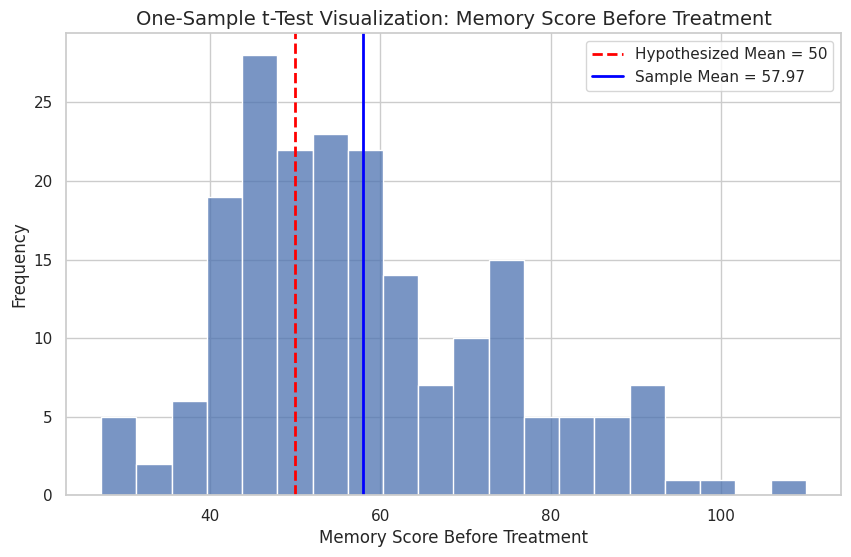

In [ ]:
# ============================================================
# Variable: Mem_Score_Before
# Hypothesized population mean: 50
# ============================================================

# Choose the sample data
sample_data = df["Mem_Score_Before"]

# Define hypothesized population mean
hypothesized_mean = 50

# Create histogram
plt.figure(figsize=(10, 6))

sns.histplot(sample_data, bins=20)

# Add vertical line for hypothesized mean
plt.axvline(
    hypothesized_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Hypothesized Mean = {hypothesized_mean}"
)

# Add actual sample mean line
plt.axvline(
    sample_data.mean(),
    color="blue",
    linestyle="-",
    linewidth=2,
    label=f"Sample Mean = {sample_data.mean():.2f}"
)

# Titles and labels
plt.title("One-Sample t-Test Visualization: Memory Score Before Treatment", fontsize=14)
plt.xlabel("Memory Score Before Treatment")
plt.ylabel("Frequency")
plt.legend()

plt.show()

This histogram shows the distribution of memory scores before treatment.  
The red dashed vertical line represents the hypothesized population mean of 50.  
The blue vertical line represents the actual sample mean of the memory scores before treatment.

This visualization helps us see whether the sample mean appears close to or far from the hypothesized population mean before performing the one-sample t-test.

# Part 1.2: Independent Two-Sample t-Test Visualization

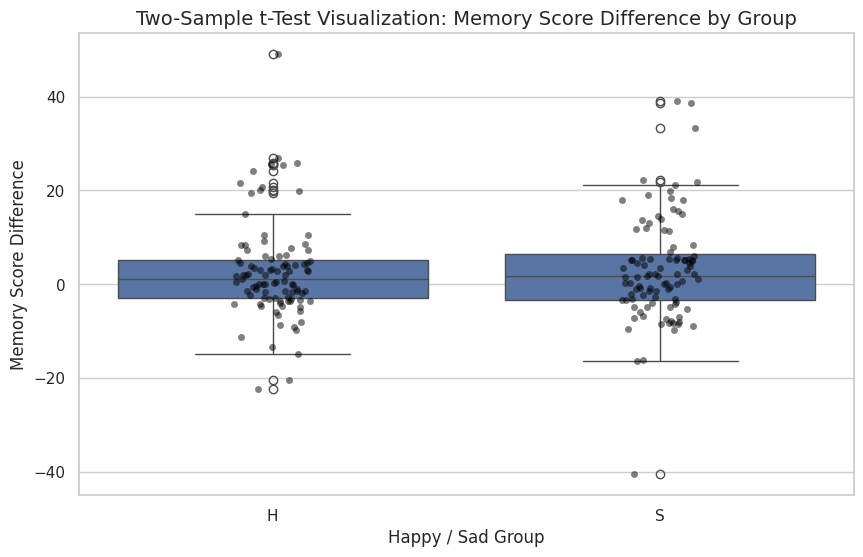

In [ ]:
# ============================================================
# Variable: Diff
# Groups: Happy_Sad_group
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Happy_Sad_group",
    y="Diff"
)

sns.stripplot(
    data=df,
    x="Happy_Sad_group",
    y="Diff",
    color="black",
    alpha=0.5,
    jitter=True
)

plt.title("Two-Sample t-Test Visualization: Memory Score Difference by Group", fontsize=14)
plt.xlabel("Happy / Sad Group")
plt.ylabel("Memory Score Difference")
plt.show()

This boxplot compares the memory score difference between the two independent groups: the happy group and the sad group.

The variable Diff represents the change in memory score after treatment.  
The boxplot shows the median, spread, and possible outliers for each group.  
The black dots represent individual participant values.

This visualization helps us compare whether the average memory score change appears different between the two groups before performing the independent two-sample t-test.

# Part 1.2 Alternative: Two-Sample t-Test Histogram


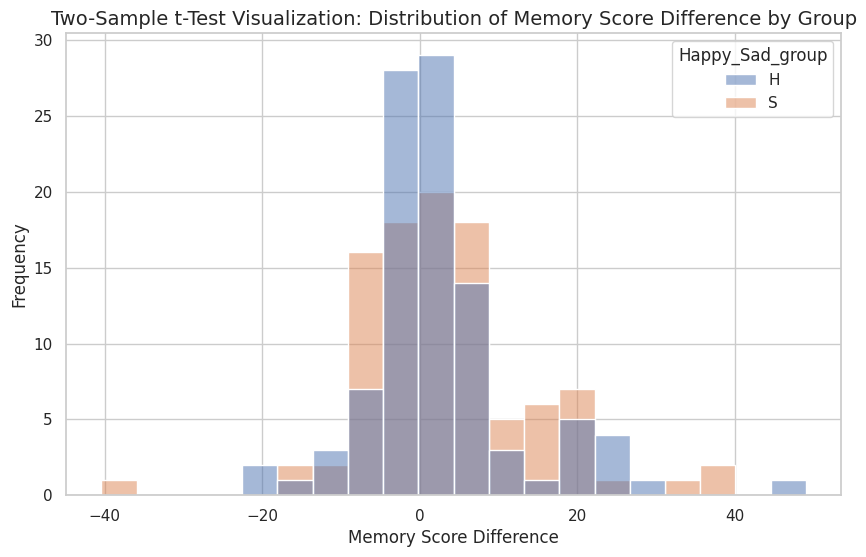

In [ ]:
# ============================================================
# Variable: Diff
# Groups: Happy_Sad_group
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Diff",
    hue="Happy_Sad_group",
    bins=20,
    alpha=0.5
)

plt.title("Two-Sample t-Test Visualization: Distribution of Memory Score Difference by Group", fontsize=14)
plt.xlabel("Memory Score Difference")
plt.ylabel("Frequency")
plt.show()

# Part 1.3: Paired t-Test Visualization

For the paired t-test, we compare the same participants’ memory scores:


*   Mem_Score_Before
*   Mem_Score_After






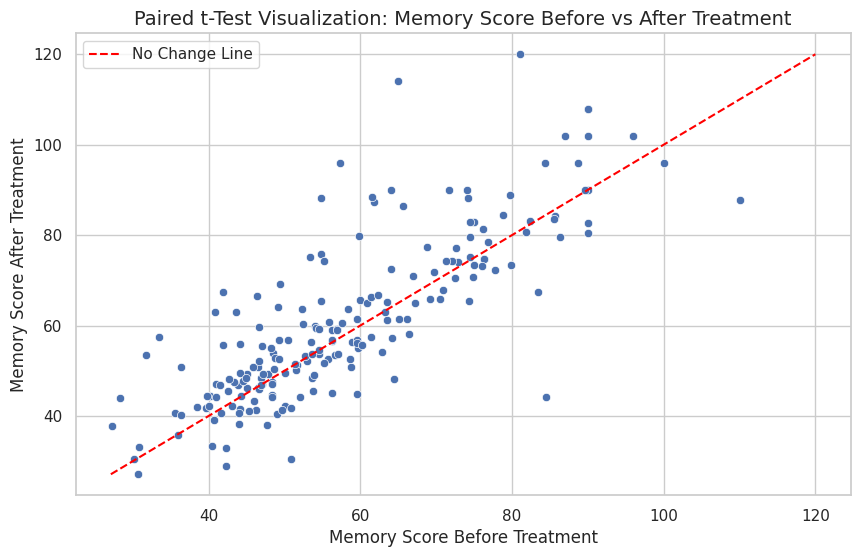

In [ ]:
# ============================================================
# Variables: Mem_Score_Before and Mem_Score_After
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Mem_Score_Before",
    y="Mem_Score_After"
)

# Add reference line where before = after
min_score = min(df["Mem_Score_Before"].min(), df["Mem_Score_After"].min())
max_score = max(df["Mem_Score_Before"].max(), df["Mem_Score_After"].max())

plt.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--",
    color="red",
    label="No Change Line"
)

plt.title("Paired t-Test Visualization: Memory Score Before vs After Treatment", fontsize=14)
plt.xlabel("Memory Score Before Treatment")
plt.ylabel("Memory Score After Treatment")
plt.legend()

plt.show()

This scatter plot compares memory scores before and after treatment for the same participants.


Each point represents one participant.  
The red dashed line represents the no-change line, where the before-treatment score and after-treatment score are equal.


Points above the red line indicate participants whose memory score increased after treatment.  
Points below the red line indicate participants whose memory score decreased after treatment.


This visualization helps us observe whether memory scores changed after treatment before performing the paired t-test.

# Part 2.1: One-Sample t-Test Result Table


H₀: The mean memory score before treatment is equal to 50.

H₁: The mean memory score before treatment is different from 50.

In [ ]:
# ============================================================
# Variable: Mem_Score_Before
# Hypothesized mean: 50
# ============================================================

# Select data
sample_data = df["Mem_Score_Before"]

# Define hypothesized population mean
hypothesized_mean = 50

# Define significance level
alpha = 0.05

# Run one-sample t-test
t_statistic, p_value = stats.ttest_1samp(
    sample_data,
    popmean=hypothesized_mean
)

# Calculate sample size
n = len(sample_data)

# Calculate sample mean
sample_mean = sample_data.mean()

# Calculate mean difference
mean_difference = sample_mean - hypothesized_mean

# Degrees of freedom
degrees_freedom = n - 1

# Decision
if p_value < alpha:
    decision = "Reject H0"
else:
    decision = "Fail to Reject H0"

# Create result table without rounding
one_sample_result = pd.DataFrame({
    "Item": [
        "Null Hypothesis (H0)",
        "Alternative Hypothesis (Ha)",
        "Sample Size",
        "Sample Mean",
        "Hypothesized Mean",
        "Mean Difference",
        "t-statistic",
        "Degrees of Freedom",
        "p-value",
        "p-value Scientific Notation",
        "Significance Level (alpha)",
        "Decision"
    ],
    "Result": [
        "The mean memory score before treatment is equal to 50.",
        "The mean memory score before treatment is different from 50.",
        n,
        sample_mean,
        hypothesized_mean,
        mean_difference,
        t_statistic,
        degrees_freedom,
        p_value,
        f"{p_value:.10e}",
        alpha,
        decision
    ]
})

# Make long text visible
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
one_sample_result

,Item,Result
0,Null Hypothesis (H0),The mean memory score before treatment is equal to 50.
1,Alternative Hypothesis (Ha),The mean memory score before treatment is different from 50.
2,Sample Size,198
3,Sample Mean,57.967677
4,Hypothesized Mean,50
5,Mean Difference,7.967677
6,t-statistic,7.111195
7,Degrees of Freedom,197
8,p-value,0.0
9,p-value Scientific Notation,2.0737734592e-11


### Interpretation of One-Sample t-Test

The one-sample t-test was used to determine whether the average memory score before treatment was significantly different from the chosen reference value of 50.

The null hypothesis stated that the mean memory score before treatment is equal to 50. The alternative hypothesis stated that the mean memory score before treatment is different from 50.

The sample mean was approximately 57.97, which is higher than the hypothesized mean of 50. The p-value was extremely small, approximately \(2.07 \times 10^{-11}\), which is less than the significance level of 0.05.

Therefore, the null hypothesis is rejected.

This means there is statistically significant evidence that the average memory score before treatment is different from the reference value of 50. Since the sample mean is higher than 50, the participants’ average memory score before treatment was significantly above the selected reference score.

In [ ]:
print("t-statistic:", t_statistic)
print("p-value:", p_value)
print("p-value in scientific notation:", f"{p_value:.10e}")

t-statistic: 7.111195086365472
p-value: 2.0737734592037636e-11
p-value in scientific notation: 2.0737734592e-11


t-statistic → how far the sample mean is from 50 in standard error units

p-value     → whether that difference is statistically significant

If p-value < 0.05 → Reject H0

If p-value ≥ 0.05 → Fail to Reject H0

# Part 2.2: Independent Two-Sample t-Test Result Table


In [ ]:
# ============================================================
# Variable: Diff
# Groups: Happy_Sad_group
# ============================================================

# Define significance level
alpha = 0.05

# Check the two groups available in Happy_Sad_group
group_names = df["Happy_Sad_group"].unique()

print("Groups found:", group_names)

# Separate the two independent groups
group1_name = group_names[0]
group2_name = group_names[1]

group1_data = df[df["Happy_Sad_group"] == group1_name]["Diff"]
group2_data = df[df["Happy_Sad_group"] == group2_name]["Diff"]

# Run independent two-sample t-test
# equal_var=True means we are using the classic Student's independent t-test
t_statistic, p_value = stats.ttest_ind(
    group1_data,
    group2_data,
    equal_var=True
)

# Sample sizes
n1 = len(group1_data)
n2 = len(group2_data)

# Sample means
mean1 = group1_data.mean()
mean2 = group2_data.mean()

# Mean difference
mean_difference = mean1 - mean2

# Degrees of freedom for classic independent two-sample t-test
degrees_freedom = n1 + n2 - 2

# Decision
if p_value < alpha:
    decision = "Reject H0"
else:
    decision = "Fail to Reject H0"

# Create result table without rounding
two_sample_result = pd.DataFrame({
    "Item": [
        "Null Hypothesis (H0)",
        "Alternative Hypothesis (Ha)",
        "Group 1",
        "Group 2",
        "Sample Size Group 1",
        "Sample Size Group 2",
        "Sample Mean Group 1",
        "Sample Mean Group 2",
        "Mean Difference",
        "t-statistic",
        "Degrees of Freedom",
        "p-value",
        "p-value Scientific Notation",
        "Significance Level (alpha)",
        "Decision"
    ],
    "Result": [
        f"The mean memory score difference is the same for {group1_name} and {group2_name}.",
        f"The mean memory score difference is different between {group1_name} and {group2_name}.",
        group1_name,
        group2_name,
        n1,
        n2,
        mean1,
        mean2,
        mean_difference,
        t_statistic,
        degrees_freedom,
        p_value,
        round(p_value, 4),
        alpha,
        decision
    ]
})

# Make long text visible
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
two_sample_result

Groups found: ['H' 'S']


,Item,Result
0,Null Hypothesis (H0),The mean memory score difference is the same for H and S.
1,Alternative Hypothesis (Ha),The mean memory score difference is different between H and S.
2,Group 1,H
3,Group 2,S
4,Sample Size Group 1,99
5,Sample Size Group 2,99
6,Sample Mean Group 1,2.733333
7,Sample Mean Group 2,3.175758
8,Mean Difference,-0.442424
9,t-statistic,-0.288758


### Interpretation of Independent Two-Sample t-Test

The independent two-sample t-test was used to compare the average memory score difference between the Happy group and the Sad group.

The null hypothesis stated that the mean memory score difference is the same for both groups. The alternative hypothesis stated that the mean memory score difference is different between the two groups.

The Happy group had an average memory score difference of approximately 2.73, while the Sad group had an average memory score difference of approximately 3.18. Although the Sad group had a slightly higher mean difference, the p-value was approximately 0.7731, which is greater than the significance level of 0.05.

Therefore, the null hypothesis is not rejected.

This means there is no statistically significant evidence that the memory score difference is different between the Happy group and the Sad group. In other words, based on this sample, the emotional group condition does not appear to create a significant difference in memory score change.

# Part 2.3: Paired t-Test Result Table


In [ ]:
# ============================================================
# Variables: Mem_Score_Before and Mem_Score_After
# ============================================================

# Define significance level
alpha = 0.05

# Select paired data
before_scores = df["Mem_Score_Before"]
after_scores = df["Mem_Score_After"]

# Calculate difference: After - Before
paired_differences = after_scores - before_scores

# Run paired t-test
t_statistic, p_value = stats.ttest_rel(
    after_scores,
    before_scores
)

# Sample size
n = len(before_scores)

# Sample means
mean_before = before_scores.mean()
mean_after = after_scores.mean()

# Mean difference
mean_difference = paired_differences.mean()

# Degrees of freedom
degrees_freedom = n - 1

# Decision
if p_value < alpha:
    decision = "Reject H0"
else:
    decision = "Fail to Reject H0"

# Create paired t-test result table
paired_sample_result = pd.DataFrame({
    "Item": [
        "Null Hypothesis (H0)",
        "Alternative Hypothesis (Ha)",
        "Sample Size",
        "Mean Before Treatment",
        "Mean After Treatment",
        "Mean Difference",
        "t-statistic",
        "Degrees of Freedom",
        "p-value",
        "p-value Scientific Notation",
        "Significance Level (alpha)",
        "Decision"
    ],
    "Result": [
        "The mean difference between memory scores before and after treatment is equal to 0.",
        "The mean difference between memory scores before and after treatment is not equal to 0.",
        n,
        mean_before,
        mean_after,
        mean_difference,
        t_statistic,
        degrees_freedom,
        p_value,
        f"{p_value:.10e}",
        alpha,
        decision
    ]
})

# Make long text visible
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Display table clearly
paired_sample_result.style.set_properties(
    subset=["Result"],
    **{
        "text-align": "left",
        "white-space": "normal",
        "width": "700px"
    }
)

,Item,Result
0,Null Hypothesis (H0),The mean difference between memory scores before and after treatment is equal to 0.
1,Alternative Hypothesis (Ha),The mean difference between memory scores before and after treatment is not equal to 0.
2,Sample Size,198
3,Mean Before Treatment,57.967677
4,Mean After Treatment,60.922222
5,Mean Difference,2.954545
6,t-statistic,3.865707
7,Degrees of Freedom,197
8,p-value,0.000150
9,p-value Scientific Notation,1.5035646624e-04


### Interpretation of Paired t-Test

The paired t-test was used to determine whether participants’ memory scores changed significantly after treatment. This test is appropriate because the before-treatment and after-treatment memory scores were collected from the same participants.

The null hypothesis stated that the mean difference between memory scores before and after treatment is equal to 0. The alternative hypothesis stated that the mean difference is not equal to 0.

The average memory score before treatment was approximately 57.97, while the average memory score after treatment was approximately 60.92. The mean difference was approximately 2.95, meaning that memory scores increased after treatment on average.

The p-value was approximately 0.00015, which is less than the significance level of 0.05.

Therefore, the null hypothesis is rejected.

This means there is statistically significant evidence that participants’ memory scores changed after treatment. Since the mean difference is positive, the results suggest that memory scores increased significantly after treatment.

# Part 4.1: 95% Confidence Interval for One-Sample t-Test

In [ ]:
# ============================================================
# Variable: Mem_Score_Before
# ============================================================

# Select sample data
sample_data = df["Mem_Score_Before"]

# Significance level
alpha = 0.05

# Sample size
n = len(sample_data)

# Sample mean
sample_mean = sample_data.mean()

# Sample standard deviation
sample_std = sample_data.std(ddof=1)

# Standard error
standard_error = sample_std / np.sqrt(n)

# Degrees of freedom
degrees_freedom = n - 1

# t critical value for 95% confidence interval
t_critical = stats.t.ppf(1 - alpha/2, degrees_freedom)

# Margin of error
margin_error = t_critical * standard_error

# Confidence interval
ci_lower = sample_mean - margin_error
ci_upper = sample_mean + margin_error

# Create confidence interval table
one_sample_ci = pd.DataFrame({
    "Item": [
        "Sample Mean",
        "Sample Standard Deviation",
        "Sample Size",
        "Degrees of Freedom",
        "Confidence Level",
        "Standard Error",
        "t Critical Value",
        "Margin of Error",
        "Lower Bound",
        "Upper Bound"
    ],
    "Result": [
        sample_mean,
        sample_std,
        n,
        degrees_freedom,
        "95%",
        standard_error,
        t_critical,
        margin_error,
        ci_lower,
        ci_upper
    ]
})

one_sample_ci

,Item,Result
0,Sample Mean,57.967677
1,Sample Standard Deviation,15.766007
2,Sample Size,198
3,Degrees of Freedom,197
4,Confidence Level,95%
5,Standard Error,1.120441
6,t Critical Value,1.972079
7,Margin of Error,2.209599
8,Lower Bound,55.758078
9,Upper Bound,60.177276


### 95% Confidence Interval Interpretation: One-Sample t-Test

The 95% confidence interval estimates the range in which the true population mean memory score before treatment is likely to fall.

For this dataset, the confidence interval was calculated using the sample mean, sample standard deviation, sample size, and the t-distribution.

If we repeated this sampling process many times, approximately 95% of the confidence intervals created in the same way would contain the true population mean.

In this analysis, the confidence interval provides a reasonable estimated range for the average memory score before treatment.

# Part 4.2: 95% Confidence Interval for Independent Two-Sample t-Test


In [ ]:
# ============================================================
# Variable: Diff
# Groups: Happy_Sad_group
# ============================================================

# Define significance level
alpha = 0.05

# Get group names
group_names = df["Happy_Sad_group"].unique()

group1_name = group_names[0]
group2_name = group_names[1]

# Separate the two groups
group1_data = df[df["Happy_Sad_group"] == group1_name]["Diff"]
group2_data = df[df["Happy_Sad_group"] == group2_name]["Diff"]

# Sample sizes
n1 = len(group1_data)
n2 = len(group2_data)

# Sample means
mean1 = group1_data.mean()
mean2 = group2_data.mean()

# Sample standard deviations
std1 = group1_data.std(ddof=1)
std2 = group2_data.std(ddof=1)

# Mean difference
mean_difference = mean1 - mean2

# Degrees of freedom for equal variance independent t-test
degrees_freedom = n1 + n2 - 2

# Pooled variance
pooled_variance = (((n1 - 1) * std1**2) + ((n2 - 1) * std2**2)) / degrees_freedom

# Standard error of the difference between means
standard_error = np.sqrt(pooled_variance * ((1 / n1) + (1 / n2)))

# t critical value for 95% confidence interval
t_critical = stats.t.ppf(1 - alpha/2, degrees_freedom)

# Margin of error
margin_error = t_critical * standard_error

# Confidence interval
ci_lower = mean_difference - margin_error
ci_upper = mean_difference + margin_error

# Create confidence interval table
two_sample_ci = pd.DataFrame({
    "Item": [
        "Group 1",
        "Group 2",
        "Mean Group 1",
        "Mean Group 2",
        "Mean Difference",
        "Standard Deviation Group 1",
        "Standard Deviation Group 2",
        "Sample Size Group 1",
        "Sample Size Group 2",
        "Degrees of Freedom",
        "Confidence Level",
        "Standard Error",
        "t Critical Value",
        "Margin of Error",
        "Lower Bound",
        "Upper Bound"
    ],
    "Result": [
        group1_name,
        group2_name,
        mean1,
        mean2,
        mean_difference,
        std1,
        std2,
        n1,
        n2,
        degrees_freedom,
        "95%",
        standard_error,
        t_critical,
        margin_error,
        ci_lower,
        ci_upper
    ]
})

two_sample_ci

,Item,Result
0,Group 1,H
1,Group 2,S
2,Mean Group 1,2.733333
3,Mean Group 2,3.175758
4,Mean Difference,-0.442424
5,Standard Deviation Group 1,10.339857
6,Standard Deviation Group 2,11.202306
7,Sample Size Group 1,99
8,Sample Size Group 2,99
9,Degrees of Freedom,196


### 95% Confidence Interval Interpretation: Independent Two-Sample t-Test

The 95% confidence interval estimates the plausible range for the true difference between the mean memory score changes of the two independent groups.

In this test, the confidence interval was calculated for the difference between the mean `Diff` value of the Happy group and the mean `Diff` value of the Sad group.

The mean difference was calculated as:

`Mean Difference = Mean of Group 1 - Mean of Group 2`

The confidence interval shows the range of values in which the true difference between the two population means is likely to fall.

If the confidence interval includes 0, it suggests that there may be no meaningful difference between the two group means. If the confidence interval does not include 0, it suggests that the group means may be significantly different.

In this analysis, the confidence interval helps support the independent two-sample t-test result by showing whether 0 is a plausible value for the difference between the Happy and Sad group mean memory score changes.

# Part 4.3: 95% Confidence Interval for Paired t-Test


In [ ]:
# ============================================================
# Variables: Mem_Score_Before and Mem_Score_After
# ============================================================

# Define significance level
alpha = 0.05

# Select before and after scores
before_scores = df["Mem_Score_Before"]
after_scores = df["Mem_Score_After"]

# Calculate paired differences
paired_differences = after_scores - before_scores

# Sample size
n = len(paired_differences)

# Mean difference
mean_difference = paired_differences.mean()

# Standard deviation of differences
std_difference = paired_differences.std(ddof=1)

# Standard error of mean difference
standard_error = std_difference / np.sqrt(n)

# Degrees of freedom
degrees_freedom = n - 1

# t critical value for 95% confidence interval
t_critical = stats.t.ppf(1 - alpha/2, degrees_freedom)

# Margin of error
margin_error = t_critical * standard_error

# Confidence interval
ci_lower = mean_difference - margin_error
ci_upper = mean_difference + margin_error

# Create confidence interval table
paired_ci = pd.DataFrame({
    "Item": [
        "Mean Before Treatment",
        "Mean After Treatment",
        "Mean Difference",
        "Standard Deviation of Differences",
        "Sample Size",
        "Degrees of Freedom",
        "Confidence Level",
        "Standard Error",
        "t Critical Value",
        "Margin of Error",
        "Lower Bound",
        "Upper Bound"
    ],
    "Result": [
        before_scores.mean(),
        after_scores.mean(),
        mean_difference,
        std_difference,
        n,
        degrees_freedom,
        "95%",
        standard_error,
        t_critical,
        margin_error,
        ci_lower,
        ci_upper
    ]
})

paired_ci

,Item,Result
0,Mean Before Treatment,57.967677
1,Mean After Treatment,60.922222
2,Mean Difference,2.954545
3,Standard Deviation of Differences,10.754603
4,Sample Size,198
5,Degrees of Freedom,197
6,Confidence Level,95%
7,Standard Error,0.764296
8,t Critical Value,1.972079
9,Margin of Error,1.507253


### 95% Confidence Interval Interpretation: Paired t-Test

The 95% confidence interval estimates the plausible range for the true mean difference between memory scores before and after treatment.

For the paired t-test, the difference was calculated as:

`Difference = Mem_Score_After - Mem_Score_Before`

This means a positive difference indicates that memory scores increased after treatment, while a negative difference indicates that memory scores decreased after treatment.

The confidence interval was calculated using the mean of the paired differences, the standard deviation of the paired differences, the sample size, and the t-distribution.

If the confidence interval includes 0, it suggests that there may be no significant average change between the before-treatment and after-treatment scores. If the confidence interval does not include 0, it suggests that the average change is statistically significant.

In this analysis, the confidence interval helps support the paired t-test result by showing whether 0 is a plausible value for the true mean memory score change.

In [ ]:
g - drug a

SyntaxError: invalid syntax (1968427910.py, line 1)

In [ ]:
g 2 - grus s

In [ ]:
Drug t -- dont use

In [ ]:
# ============================================================
# Part 2.2: Independent Two-Sample t-Test Result Table
# Variable: Diff
# Groups: Drug A and Drug S
# ============================================================

# Define significance level
alpha = 0.05

# Filter only Drug A and Drug S
drug_data = df[df["Drug"].isin(["A", "S"])]

# Separate the two independent groups
group1_name = "A"
group2_name = "S"

group1_data = drug_data[drug_data["Drug"] == group1_name]["Diff"]
group2_data = drug_data[drug_data["Drug"] == group2_name]["Diff"]

# Run independent two-sample t-test
t_statistic, p_value = stats.ttest_ind(
    group1_data,
    group2_data,
    equal_var=True
)

# Sample sizes
n1 = len(group1_data)
n2 = len(group2_data)

# Sample means
mean1 = group1_data.mean()
mean2 = group2_data.mean()

# Mean difference
mean_difference = mean1 - mean2

# Degrees of freedom
degrees_freedom = n1 + n2 - 2

# Decision
if p_value < alpha:
    decision = "Reject H0"
else:
    decision = "Fail to Reject H0"

# Create result table
two_sample_result = pd.DataFrame({
    "Item": [
        "Null Hypothesis (H0)",
        "Alternative Hypothesis (Ha)",
        "Group 1",
        "Group 2",
        "Sample Size Group 1",
        "Sample Size Group 2",
        "Sample Mean Group 1",
        "Sample Mean Group 2",
        "Mean Difference",
        "t-statistic",
        "Degrees of Freedom",
        "p-value",
        "p-value Scientific Notation",
        "Significance Level (alpha)",
        "Decision"
    ],
    "Result": [
        "The mean memory score difference is the same for Drug A and Drug S.",
        "The mean memory score difference is different between Drug A and Drug S.",
        "Drug A",
        "Drug S",
        n1,
        n2,
        mean1,
        mean2,
        mean_difference,
        t_statistic,
        degrees_freedom,
        p_value,
        f"{p_value:.10e}",
        alpha,
        decision
    ]
})

# Display clearly
pd.set_option("display.max_colwidth", None)

two_sample_result.style.set_properties(
    subset=["Result"],
    **{
        "text-align": "left",
        "white-space": "normal",
        "width": "700px"
    }
)

,Item,Result
0,Null Hypothesis (H0),The mean memory score difference is the same for Drug A and Drug S.
1,Alternative Hypothesis (Ha),The mean memory score difference is different between Drug A and Drug S.
2,Group 1,Drug A
3,Group 2,Drug S
4,Sample Size Group 1,67
5,Sample Size Group 2,66
6,Sample Mean Group 1,9.470149
7,Sample Mean Group 2,-0.171212
8,Mean Difference,9.641361
9,t-statistic,5.152525


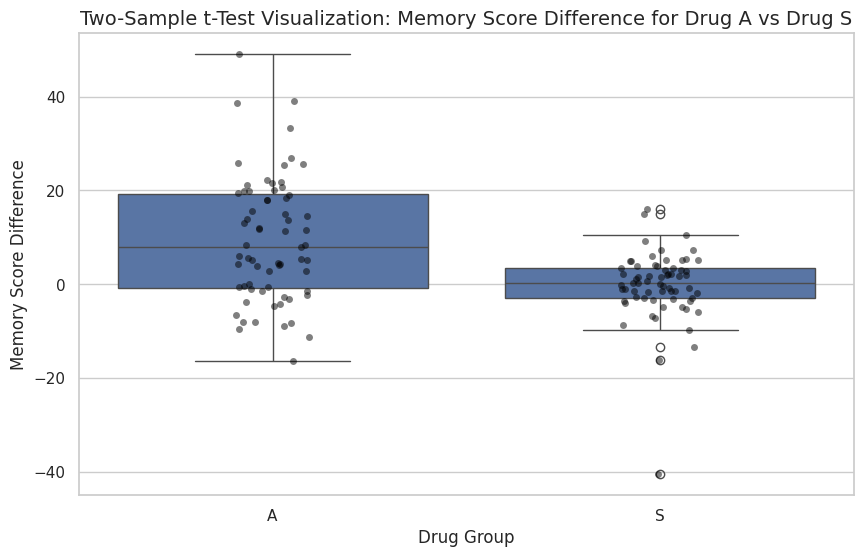

In [ ]:
# ============================================================
# Part 1.2: Independent Two-Sample t-Test Visualization
# Variable: Diff
# Groups: Drug A and Drug S
# ============================================================

drug_data = df[df["Drug"].isin(["A", "S"])]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=drug_data,
    x="Drug",
    y="Diff"
)

sns.stripplot(
    data=drug_data,
    x="Drug",
    y="Diff",
    color="black",
    alpha=0.5,
    jitter=True
)

plt.title("Two-Sample t-Test Visualization: Memory Score Difference for Drug A vs Drug S", fontsize=14)
plt.xlabel("Drug Group")
plt.ylabel("Memory Score Difference")
plt.show()